# User clustering — personas

**Goal (RQ1).** Group users into a few *personas* by the kind of movies they like: genres and production style (budget scale, era, box-office success, runtime, director / cast track record, language, country). **RQ2:** does adding a taste for polarizing movies (movie `rating_std`) improve the clustering?

Inputs come from `07_split_and_user_eda.ipynb` and use **training movies only**, so the personas carry no information about validation / test movies. Replaces `04_user_clustering.ipynb` (built on the old feature table and a user-level split).

Generosity (`user_mean`, `user_std`, number of ratings) is deliberately **not** a clustering feature: it would split users into generous vs. harsh raters instead of by taste. It enters the model directly in `09`.

## 1. Load

Eligible users (≥ 20 ratings of training movies) and their ratings of training movies.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

PROCESSED = Path("../data/processed")
RANDOM_STATE = 42

movies = pd.read_csv(PROCESSED / "movies_features.csv", usecols=lambda c: c not in {"director", "cast_top5"})
movies = (
    movies.merge(pd.read_csv(PROCESSED / "movie_split.csv"), on="netflix_movie_id")
    .merge(pd.read_csv(PROCESSED / "track_records.csv"), on="netflix_movie_id")
    .merge(pd.read_csv(PROCESSED / "movie_stats_train.csv")[["netflix_movie_id", "rating_std"]], on="netflix_movie_id", how="left")
)
train_movies = movies[movies["split"] == "train"].set_index("netflix_movie_id")
user_stats = pd.read_csv(PROCESSED / "user_stats_train.csv").set_index("rater_id")

chunks = pd.read_csv(
    PROCESSED / "ratings.csv",
    usecols=["netflix_movie_id", "rater_id", "rating"],
    dtype={"netflix_movie_id": "int32", "rater_id": "int32", "rating": "int8"},
    chunksize=5_000_000,
)
ratings = pd.concat(
    c[c["netflix_movie_id"].isin(train_movies.index) & c["rater_id"].isin(user_stats.index)] for c in chunks
).reset_index(drop=True)

print(f"training movies: {len(train_movies)} | eligible users: {len(user_stats):,} | ratings: {len(ratings):,}")

training movies: 919 | eligible users: 332,632 | ratings: 34,243,173


## 2. Movie profile features

The movie properties a user's taste is described by:
- **genres** (18 multi-hot columns),
- **production:** `runtime`, `movie_age_log`, `budget_log` (budget scale, RQ1), `log_roi` (box-office success), `director_track_record`, `cast_track_record`, `lang_en`, `non_us`,
- **polarization (RQ2):** `rating_std` of the movie on training ratings.

In [2]:
GENRE_COLS = [c for c in movies.columns if c.startswith("genre_")]
PRODUCTION_COLS = [
    "runtime",
    "movie_age_log",
    "budget_log",
    "log_roi",
    "director_track_record",
    "cast_track_record",
    "lang_en",
    "non_us",
]
STD_COL = "rating_std"
PROFILE_COLS = GENRE_COLS + PRODUCTION_COLS + [STD_COL]

movie_feat = train_movies[PROFILE_COLS]
assert movie_feat.notna().all().all()
movie_feat.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
genre_action,919.0,0.27,0.45,0.00,0.00,0.00,1.00,1.00
genre_adventure,919.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00
genre_animation,919.0,0.03,0.18,0.00,0.00,0.00,0.00,1.00
genre_comedy,919.0,0.38,0.48,0.00,0.00,0.00,1.00,1.00
genre_crime,919.0,0.19,0.39,0.00,0.00,0.00,0.00,1.00
genre_documentary,919.0,0.01,0.09,0.00,0.00,0.00,0.00,1.00
genre_drama,919.0,0.44,0.50,0.00,0.00,0.00,1.00,1.00
genre_family,919.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00
genre_fantasy,919.0,0.08,0.27,0.00,0.00,0.00,0.00,1.00
genre_history,919.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00


## 3. User taste profiles

For each user, every rated movie is weighted by how much the user liked it **relative to their own average**: `w = rating − user_mean` (positive = liked more than usual, negative = liked less). The profile is the weighted average of the movie features:

$$\text{profile}_u = \frac{\sum_i w_{ui}\, x_i}{\sum_i |w_{ui}|}$$

- Because the weights of a user sum to zero, a user who rates everything the same gets no taste, and generosity is removed by construction.
- For a genre column the value is positive when the user rates that genre above their own average, negative when below.
- For a numeric column (e.g. `runtime`) the value is positive when the user prefers movies with higher values (longer films), independent of the average level of the column.

The weights form a sparse user × movie matrix, so all profiles are one matrix product. Users with all-equal ratings (Σ|w| = 0) have no profile and are dropped.

In [3]:
user_index = pd.Index(user_stats.index)
movie_index = pd.Index(movie_feat.index)
rows = user_index.get_indexer(ratings["rater_id"])
cols = movie_index.get_indexer(ratings["netflix_movie_id"])
w = ratings["rating"].to_numpy(dtype=float) - user_stats["user_mean"].to_numpy()[rows]

W = sparse.csr_matrix((w, (rows, cols)), shape=(len(user_index), len(movie_index)))
abs_w = np.asarray(abs(W).sum(axis=1)).ravel()
has_taste = abs_w > 0

profiles = pd.DataFrame(
    (W[has_taste] @ movie_feat.to_numpy()) / abs_w[has_taste, None],
    index=user_index[has_taste],
    columns=PROFILE_COLS,
)
profiles.index.name = "rater_id"
print(f"profiles: {profiles.shape} (dropped {int((~has_taste).sum())} users with all-equal ratings)")
profiles.describe().T.round(3)

profiles: (332265, 27) (dropped 367 users with all-equal ratings)


,count,mean,std,min,25%,50%,75%,max
genre_action,332265.0,-0.022,0.097,-0.500,-0.082,-0.024,0.036,0.500
genre_adventure,332265.0,-0.003,0.079,-0.500,-0.048,-0.004,0.042,0.500
genre_animation,332265.0,0.003,0.027,-0.500,-0.002,0.000,0.011,0.500
genre_comedy,332265.0,-0.046,0.098,-0.500,-0.106,-0.047,0.013,0.500
genre_crime,332265.0,0.004,0.075,-0.500,-0.037,0.005,0.047,0.500
genre_documentary,332265.0,0.003,0.024,-0.500,0.000,0.000,0.004,0.351
genre_drama,332265.0,0.057,0.102,-0.500,-0.006,0.059,0.122,0.500
genre_family,332265.0,0.006,0.045,-0.500,-0.014,0.000,0.026,0.500
genre_fantasy,332265.0,0.010,0.048,-0.500,-0.015,0.008,0.037,0.500
genre_history,332265.0,0.015,0.037,-0.500,0.000,0.011,0.033,0.389


Correlations between profile features: strongly correlated pairs describe the same taste twice; PCA in the next step merges them.

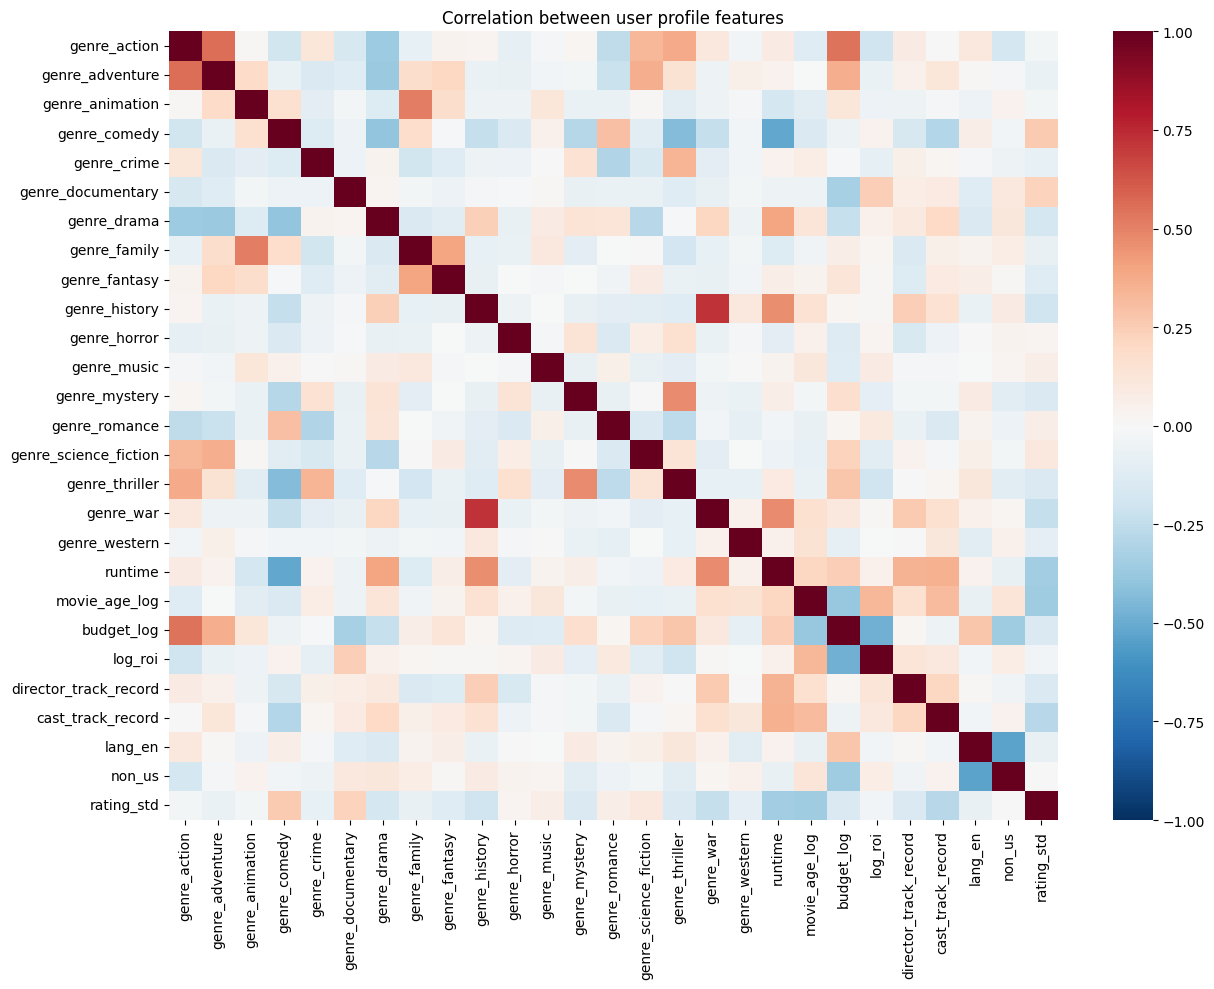

In [4]:
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(profiles.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Correlation between user profile features")
fig.tight_layout()
plt.show()

## 4. Choosing the number of personas

Two variants of the feature set are compared (RQ2):
- **with_std:** genres + production + polarization taste (`rating_std`),
- **no_std:** genres + production only.

Pipeline for each: StandardScaler → PCA keeping 90% of the variance (merges correlated features and reduces noise) → K-Means. For k = 2…10 the plots show the **silhouette** (how well separated the clusters are; computed on a 20k-user sample because it is quadratic in the number of users) and the **inertia** (elbow). Taste profiles form a continuum rather than well-separated groups, so silhouettes are expected to be low; k is chosen in 4–8, the range where personas are still few enough to describe.

with_std: 27 features -> 19 PCA components
no_std: 26 features -> 18 PCA components


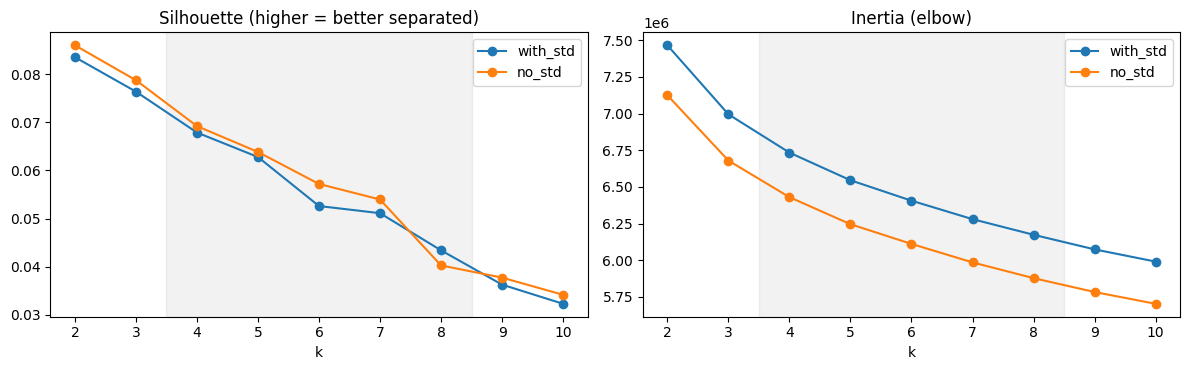

with_std                  no_std             
   silhouette      inertia silhouette      inertia
k                                                 
2       0.084  7465671.472      0.086  7125061.261
3       0.076  6994860.195      0.079  6679376.418
4       0.068  6733711.135      0.069  6430076.283
5       0.063  6545259.751      0.064  6245568.222
6       0.053  6405930.191      0.057  6111209.084
7       0.051  6280030.476      0.054  5985240.390
8       0.043  6173573.636      0.040  5877896.289
9       0.036  6074001.096      0.038  5783249.452
10      0.032  5990595.336      0.034  5702954.022

In [5]:
VARIANTS = {
    "with_std": GENRE_COLS + PRODUCTION_COLS + [STD_COL],
    "no_std": GENRE_COLS + PRODUCTION_COLS,
}
K_SWEEP = list(range(2, 11))
K_RANGE = range(4, 9)
SIL_SAMPLE = 20_000

rng = np.random.default_rng(RANDOM_STATE)
sil_idx = rng.choice(len(profiles), size=SIL_SAMPLE, replace=False)

prep, sweep = {}, {}
for name, cols in VARIANTS.items():
    scaler = StandardScaler().fit(profiles[cols])
    pca = PCA(n_components=0.90, random_state=RANDOM_STATE).fit(scaler.transform(profiles[cols]))
    X = pca.transform(scaler.transform(profiles[cols]))
    prep[name] = {"cols": cols, "scaler": scaler, "pca": pca, "X": X}
    rows = []
    for k in K_SWEEP:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
        rows.append({"k": k, "silhouette": silhouette_score(X[sil_idx], km.labels_[sil_idx]), "inertia": km.inertia_})
    sweep[name] = pd.DataFrame(rows).set_index("k")
    print(f"{name}: {len(cols)} features -> {pca.n_components_} PCA components")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for name, res in sweep.items():
    axes[0].plot(res.index, res["silhouette"], marker="o", label=name)
    axes[1].plot(res.index, res["inertia"], marker="o", label=name)
for ax, title in zip(axes, ["Silhouette (higher = better separated)", "Inertia (elbow)"]):
    ax.axvspan(min(K_RANGE) - 0.5, max(K_RANGE) + 0.5, color="gray", alpha=0.1)
    ax.set_xlabel("k")
    ax.set_title(title)
    ax.legend()
fig.tight_layout()
plt.show()
pd.concat(sweep, axis=1).round(3)

**Stability.** A persona is only meaningful if it reappears when the data changes a little. For each k in the range, K-Means is fitted on two random halves of the users and both models label all users; the adjusted Rand index (ARI) between the two labelings is 1 for identical personas and ~0 for unrelated ones.

In [6]:
def stability(X, k, seed=RANDOM_STATE):
    idx = np.random.default_rng(seed).permutation(len(X))
    half_a, half_b = idx[: len(X) // 2], idx[len(X) // 2 :]
    km_a = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X[half_a])
    km_b = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X[half_b])
    return adjusted_rand_score(km_a.predict(X), km_b.predict(X))


stab = pd.DataFrame(
    {name: {k: stability(prep[name]["X"], k) for k in K_RANGE} for name in VARIANTS}
).rename_axis("k")
stab.round(3)

,with_std,no_std
k,,
4,0.967,0.979
5,0.908,0.887
6,0.762,0.911
7,0.941,0.941
8,0.372,0.912


`BEST_K` is chosen from the silhouette, elbow and stability above (see the observations at the end); the main personas use the **with_std** variant, and the **no_std** personas are kept for the RQ2 comparison in `09`.

In [7]:
BEST_K = 5

fits = {}
for name in VARIANTS:
    km = KMeans(n_clusters=BEST_K, n_init=10, random_state=RANDOM_STATE).fit(prep[name]["X"])
    fits[name] = km
    print(f"{name}: silhouette {silhouette_score(prep[name]['X'][sil_idx], km.labels_[sil_idx]):.3f}")

labels = fits["with_std"].labels_
print(f"agreement between the two variants (ARI): {adjusted_rand_score(labels, fits['no_std'].labels_):.3f}")
pd.Series(labels).value_counts(normalize=True).sort_index().mul(100).round(1).rename("% users")

with_std: silhouette 0.063
no_std: silhouette 0.064
agreement between the two variants (ARI): 0.820


0    21.7
1    17.1
2    20.0
3    19.9
4    21.3
Name: % users, dtype: float64

## 5. Describing the personas

Each row is a persona, each column a profile feature, and the colour is the persona's average **standardized** profile value (0 = average user, +1 = one standard deviation more taste for that feature than the average user). Generosity statistics are shown separately to check that the personas are about taste, not about how many stars users give.

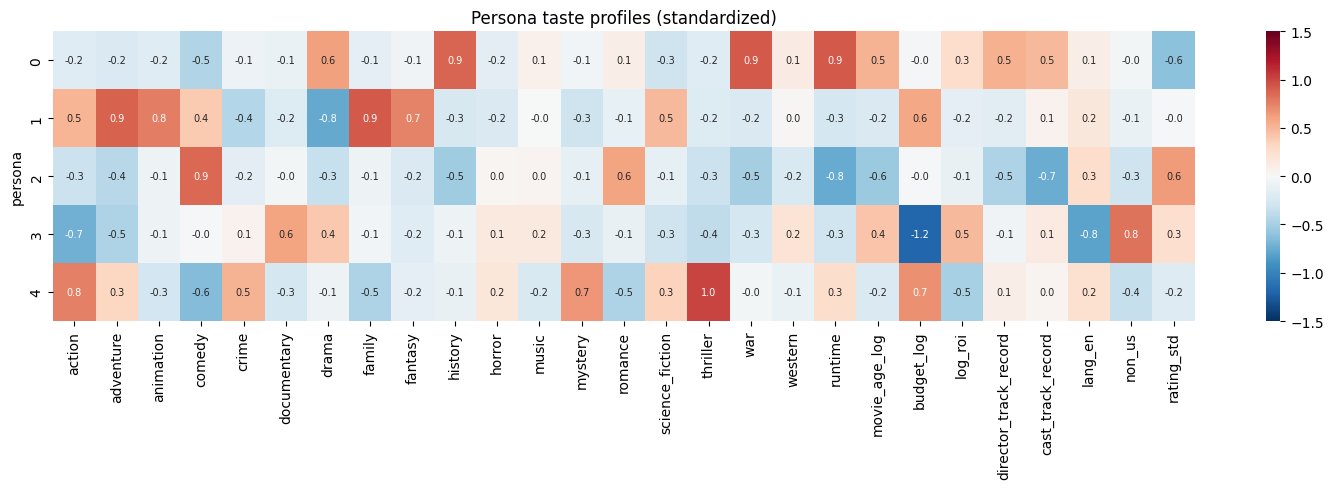

,% users,likes most,likes least,user_mean,user_std,user_n
persona,,,,,,
0,21.7,"war, runtime, history","rating_std, comedy, science_fiction",3.60,0.95,108.36
1,17.1,"family, adventure, animation","drama, crime, mystery",3.69,0.96,102.89
2,20.0,"comedy, rating_std, romance","runtime, cast_track_record, movie_age_log",3.67,0.99,96.03
3,19.9,"non_us, documentary, log_roi","budget_log, lang_en, action",3.52,1.03,111.73
4,21.3,"thriller, action, budget_log","comedy, log_roi, family",3.68,0.96,96.02


In [8]:
cols = VARIANTS["with_std"]
z = pd.DataFrame(prep["with_std"]["scaler"].transform(profiles[cols]), index=profiles.index, columns=cols)
persona_z = z.groupby(labels).mean()
persona_z.index.name = "persona"

fig, ax = plt.subplots(figsize=(15, 0.6 * BEST_K + 2))
sns.heatmap(persona_z, cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5, annot=True, fmt=".1f",
            annot_kws={"fontsize": 7}, ax=ax, xticklabels=[c.removeprefix("genre_") for c in cols])
ax.set_title("Persona taste profiles (standardized)")
fig.tight_layout()
plt.show()

summary = pd.DataFrame({
    "% users": pd.Series(labels).value_counts(normalize=True).sort_index().mul(100).round(1).to_numpy(),
    "likes most": persona_z.apply(lambda r: ", ".join(r.nlargest(3).index.str.removeprefix("genre_")), axis=1),
    "likes least": persona_z.apply(lambda r: ", ".join(r.nsmallest(3).index.str.removeprefix("genre_")), axis=1),
}, index=persona_z.index)
generosity = user_stats.loc[profiles.index, ["user_mean", "user_std", "user_n"]].groupby(labels).mean()
summary.join(generosity.round(2))

**Persona × genre scores** for the model: the average of `rating − user_mean` that each persona gives to each genre, over training movies (how much above or below their own average the persona rates the genre). In `09` a movie's `persona_genre_score` is the mean of these values over the movie's genres.

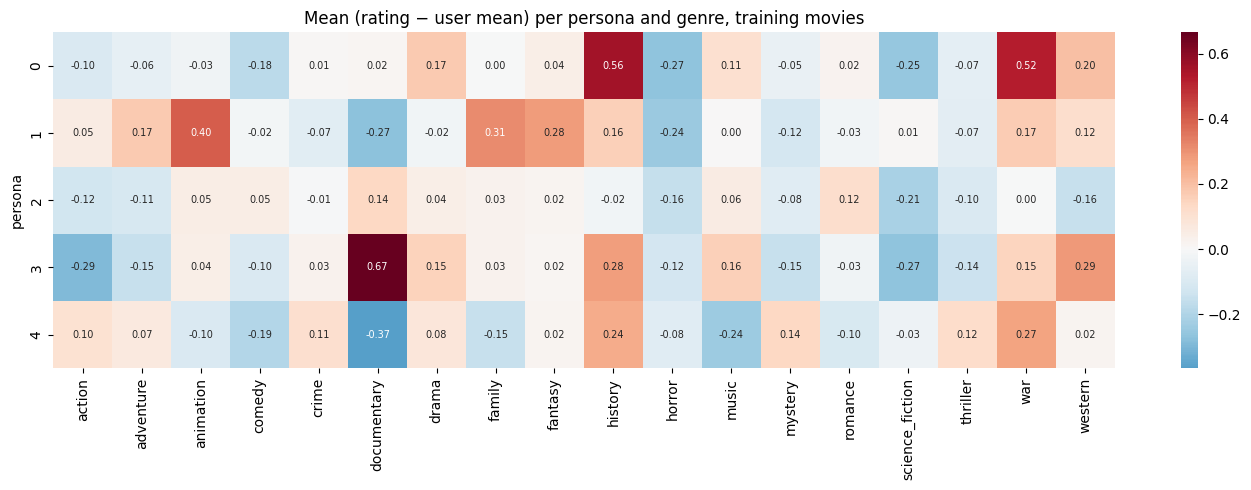

In [9]:
persona_of = pd.Series(labels, index=profiles.index)
r = ratings[ratings["rater_id"].isin(profiles.index)]
dev = r["rating"].to_numpy(dtype=float) - user_stats["user_mean"].reindex(r["rater_id"]).to_numpy()
persona = persona_of.reindex(r["rater_id"]).to_numpy()
genre_flags = train_movies[GENRE_COLS].reindex(r["netflix_movie_id"]).to_numpy()

persona_genre = pd.DataFrame({
    g.removeprefix("genre_"): pd.Series(dev[genre_flags[:, j] == 1]).groupby(persona[genre_flags[:, j] == 1]).mean()
    for j, g in enumerate(GENRE_COLS)
})
persona_genre.index.name = "persona"

fig, ax = plt.subplots(figsize=(14, 0.6 * BEST_K + 2))
sns.heatmap(persona_genre, cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"fontsize": 7}, ax=ax)
ax.set_title("Mean (rating − user mean) per persona and genre, training movies")
fig.tight_layout()
plt.show()

## 6. Save

- `user_personas.csv`: `rater_id`, `persona_id` (with_std), `persona_id_no_std` (RQ2), and the distance to each persona centre (`dist_0…`) as soft membership features for the model.
- `user_profiles.csv`: the unscaled taste profiles (model feature group C).
- `persona_genre_scores.csv`: persona × genre scores from above.

In [10]:
distances = fits["with_std"].transform(prep["with_std"]["X"])
user_personas = pd.DataFrame(
    {"persona_id": labels, "persona_id_no_std": fits["no_std"].labels_},
    index=profiles.index,
).join(pd.DataFrame(distances, index=profiles.index, columns=[f"dist_{i}" for i in range(BEST_K)]))

user_personas.reset_index().to_csv(PROCESSED / "user_personas.csv", index=False)
profiles.reset_index().to_csv(PROCESSED / "user_profiles.csv", index=False)
persona_genre.reset_index().to_csv(PROCESSED / "persona_genre_scores.csv", index=False)
print(f"user_personas: {user_personas.shape} | user_profiles: {profiles.shape} | persona_genre_scores: {persona_genre.shape}")

user_personas: (332265, 7) | user_profiles: (332265, 27) | persona_genre_scores: (5, 18)


**Observations**

- **No natural clusters, but stable personas.** Silhouettes are low (0.03–0.08) and fall steadily with k: user taste is a continuum, and the personas are a segmentation of it rather than separate groups. They are nevertheless reproducible: fitting on two random halves of the users gives ARI 0.97 (k = 4), 0.91 (k = 5) and 0.94 (k = 7), while k = 6 (0.76) and k = 8 (0.37) are unstable.
- **`BEST_K = 5`:** stable, balanced (17–22% of users each) and every persona has a clear, distinct profile. k = 4 merges two of them; k = 7 adds personas that are harder to tell apart.
- **The five personas** (from the profile heatmap and the persona × genre scores):

  | persona | name | likes (relative to own average) | dislikes |
  |---|---|---|---|
  | 0 | Classic epics | war, history, western, long films; well-agreed-on (low `rating_std`) films | comedy, sci-fi, horror, polarizing films |
  | 1 | Family & adventure | animation, family, fantasy, adventure | drama, crime, mystery, documentary |
  | 2 | Light & divisive | comedy, romance, polarizing films; short, recent films | long films, old films, films with well-rated casts |
  | 3 | Arthouse & international | non-US and non-English films, documentaries (+0.67 above own mean), small budgets | big-budget, action, sci-fi |
  | 4 | Blockbuster thrillers | thriller, action, crime, big budgets | comedy, family, music, documentary |

- **Personas are about taste, not generosity:** average user mean ranges only 3.52–3.69 across personas, user std 0.95–1.03 and number of ratings 96–112.
- **RQ2 (polarization):** adding `rating_std` changes little in cluster quality (silhouette 0.063 vs 0.064) and the two variants mostly agree (ARI 0.82). It does shape the personas' description: persona 0 avoids polarizing films and persona 2 seeks them. Whether it improves *predictions* is tested in `09` with `persona_id` vs. `persona_id_no_std`.